#### Importing Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/Users/devanshpratap28/Downloads/My Folder/MLOPS_KRISHNAIK/Network_Security/notebooks/phisingData.csv')
df.replace(-1,0,inplace=True)

In [3]:
df.head()

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,1,1,1,1,0,0,1,0,1,...,0,0,1,0,0,0,1,0,0,1
1,1,1,1,1,1,0,0,0,0,1,...,1,1,1,1,0,0,1,0,1,1
2,1,0,1,1,1,0,0,0,0,1,...,1,1,0,0,1,0,1,0,1,0
3,1,1,1,1,0,1,1,1,0,0,...,0,1,1,0,1,0,1,0,1,1
4,1,1,1,1,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0


In [4]:
sum(df.isnull().sum())

0

### EDA and Feature Engineering

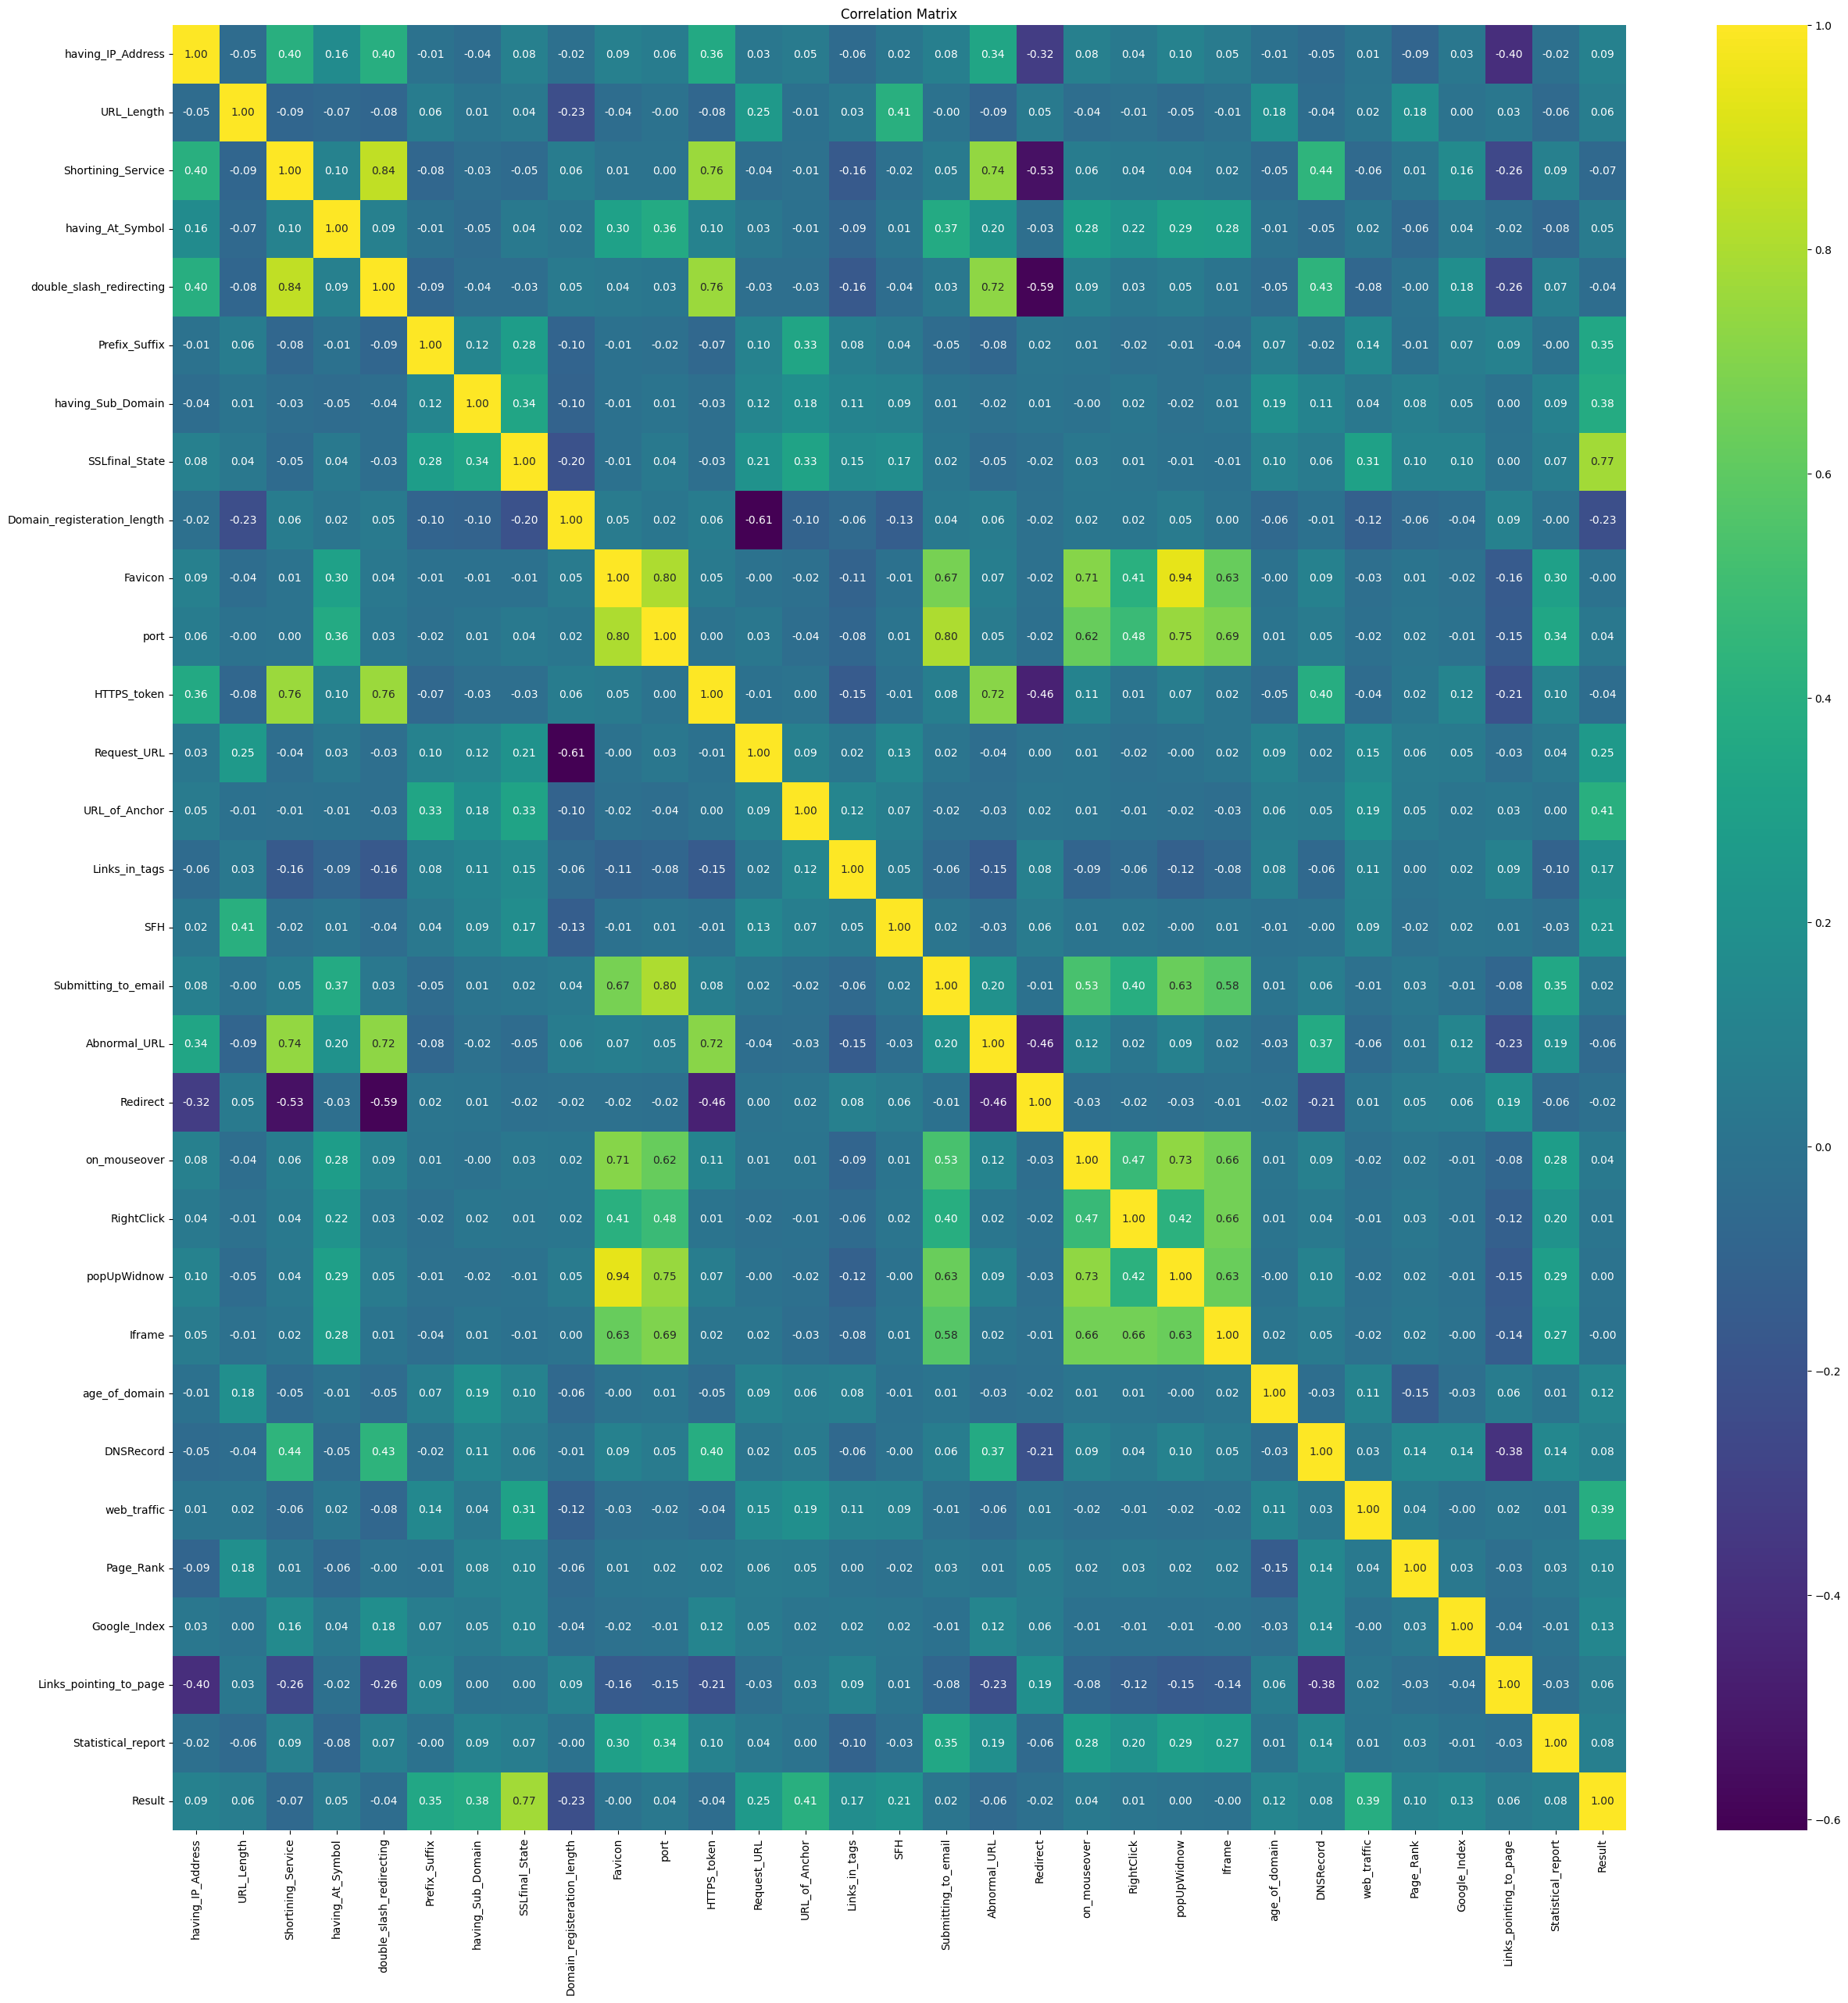

In [5]:
corr = df.corr()
plt.figure(figsize=(30,30))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

### New Created Features
> 1. url_obfuscation_cnt = `Shortining_Service` + `double_slash_redirecting` + `having_At_Symbol` + `Prefix_Suffix`

* **Reasoning:** These features represent URL manipulation techniques used to confuse users. They are highly correlated and describe the same underlying phishing behavior.

> 2. ui_deception_score = `on_mouseover` + `RightClick` + `popUpWidnow` + `Iframe`

* **Reasoning:** These represent deceptive client-side UI or JavaScript behaviors. Strong inter-correlation indicates these features are redundant when kept separate.

> 3. trust_score = `SSLfinal_State` + `HTTPS_token` + `Google_Index`

* **Reasoning:** These indicate the legitimacy and trustworthiness of a website. Combining them creates a more robust and reliable trust signal.

> redirection_risk_score = `Redirect` + `Submitting_to_email` + `Abnormal_URL`

* **Reasoning:** These features capture suspicious redirection or abnormal navigation patterns, jointly highlighting phishing intent.


In [6]:
df['url_obfuscation_score'] = df['Shortining_Service'] + df['double_slash_redirecting'] + df['having_At_Symbol'] + df['Prefix_Suffix']
df['ui_deception_score'] = df['on_mouseover'] + df['RightClick'] + df['popUpWidnow'] + df['Iframe']
df['trust_score'] = df['SSLfinal_State'] + df['HTTPS_token'] + df['Google_Index']
df['redirection_risk_score'] = df['Redirect'] + df['Submitting_to_email'] + df['Abnormal_URL']


### Dropping Features based on correlation analysis.

In [7]:
excluded_features = [
    'Shortining_Service', 'double_slash_redirecting', 'having_At_Symbol', 'Prefix_Suffix',
    'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe',
    'SSLfinal_State', 'HTTPS_token', 'Google_Index',
    'Redirect', 'Submitting_to_email', 'Abnormal_URL',
    'URL_Length', 'Domain_registeration_length', 'Favicon', 'port', 'Links_in_tags', 'SFH', 'age_of_domain', 'DNSRecord', 'Page_Rank', 'Links_pointing_to_page', 'Statistical_report'
]

In [8]:
df = df.drop(columns=excluded_features,axis=1)

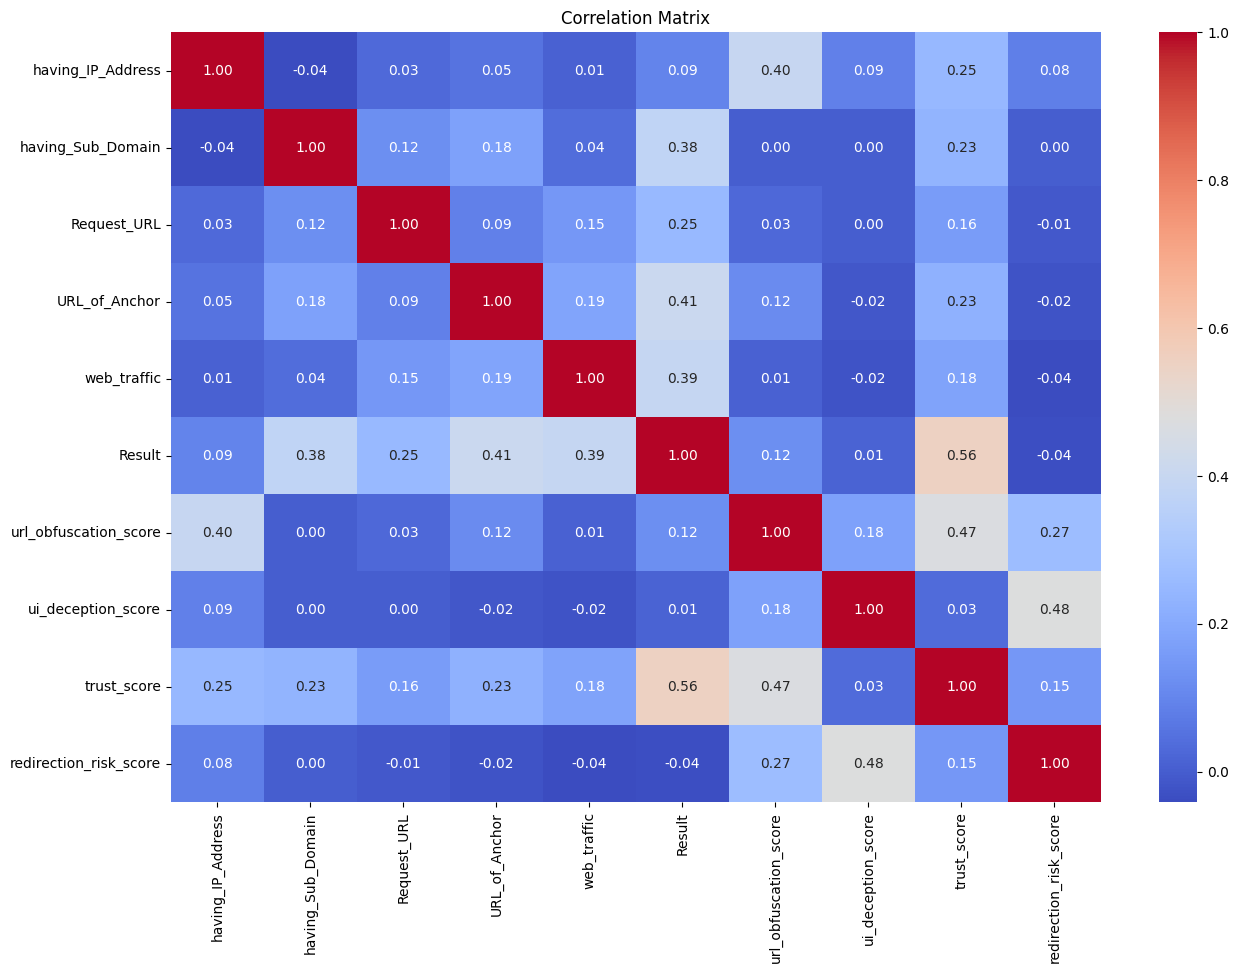

In [9]:
corr1 = df.corr()
plt.figure(figsize=(15,10))
sns.heatmap(corr1, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [10]:
df.shape

(11055, 10)

In [11]:
def calc_tar_distribution(col):
    cnt = dict(col.value_counts())
    print(f"Number of Legitimate URLs: {cnt[0]}")
    print(f"Number of Phishing URLs: {cnt[1]}")
    print(f"Percentage of Legitimate URLs: {cnt[0]/(cnt[0]+cnt[1])*100:.2f}%")
    print(f"Percentage of Phishing URLs: {cnt[1]/(cnt[0]+cnt[1])*100:.2f}%")
    return cnt


In [12]:
cnt = calc_tar_distribution(df['Result'])

Number of Legitimate URLs: 4898
Number of Phishing URLs: 6157
Percentage of Legitimate URLs: 44.31%
Percentage of Phishing URLs: 55.69%


#### Observations : Dataset is slightly imbalanced with around 55% Legitimate and 45% Phishing URLs. This should be manageable and hence no special techniques like undersampling/oversampling are required.

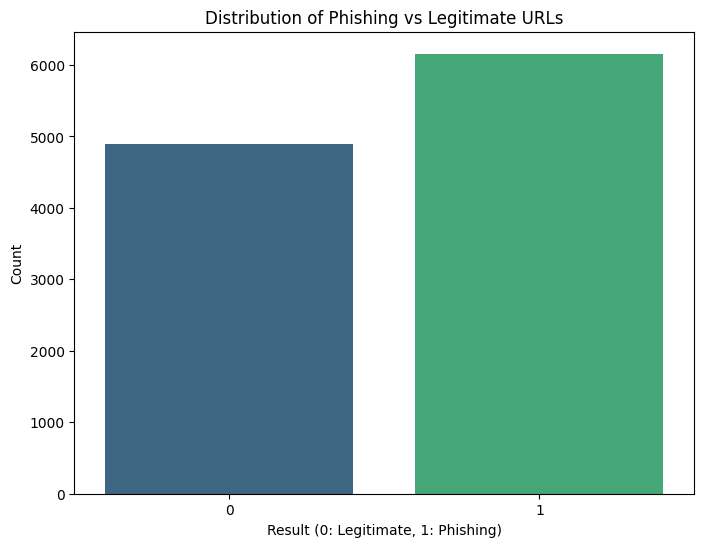

In [13]:
# sns countplot
plt.figure(figsize=(8,6))
sns.countplot(x='Result', data=df,palette='viridis')
plt.title('Distribution of Phishing vs Legitimate URLs')
plt.xlabel('Result (0: Legitimate, 1: Phishing)')
plt.ylabel('Count')
plt.show()

In [14]:
X = df.drop('Result', axis=1)
y = df['Result']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratified-split to maintain class distribution


In [16]:
calc_tar_distribution(y_train)

Number of Legitimate URLs: 3918
Number of Phishing URLs: 4926
Percentage of Legitimate URLs: 44.30%
Percentage of Phishing URLs: 55.70%


{1: 4926, 0: 3918}

In [17]:
calc_tar_distribution(y_test)

Number of Legitimate URLs: 980
Number of Phishing URLs: 1231
Percentage of Legitimate URLs: 44.32%
Percentage of Phishing URLs: 55.68%


{1: 1231, 0: 980}

### Model Training and Evaluation

In [18]:
metrics_df = pd.DataFrame(
    columns=['Model', 'Accuracy', 'Precision', 'Recall']
)

In [19]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

def metrics_calc(model_name:str,y_pred,table:pd.DataFrame):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Insert values in the given table
    table.loc[len(table)] = [model_name, accuracy, precision, recall]

    return table

In [20]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

In [21]:
y_pred_log_reg = log_reg.predict(X_test)

Model: Logistic Regression
Accuracy: 0.8625
Precision: 0.8892
Recall: 0.8603


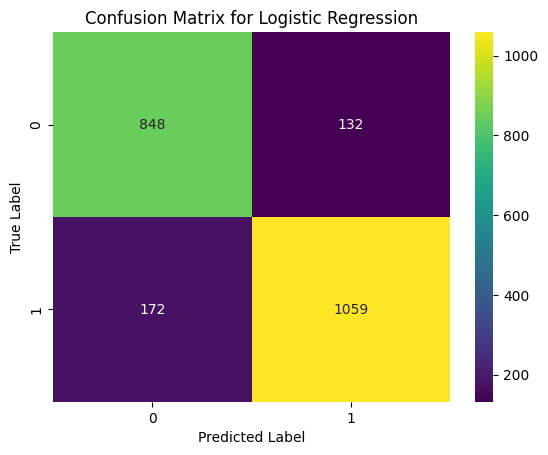

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276


In [22]:
metrics_calc("Logistic Regression", y_pred_log_reg, metrics_df)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

KNeighborsClassifier()

In [24]:
y_pred_knn = knn_clf.predict(X_test)

Model: KNN
Accuracy: 0.8851
Precision: 0.9122
Recall: 0.8781


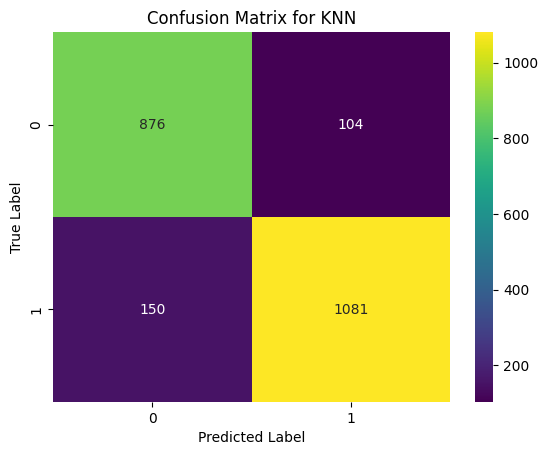

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276
1,KNN,0.885120,0.912236,0.878148


In [25]:
metrics_calc("KNN", y_pred_knn, metrics_df)

In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
svc = SVC()
# param grid for SVC
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10],
        'class_weight': [None, 'balanced']
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.5, 0.1],
        'class_weight': [None, 'balanced']
    }
]
svc_grid = GridSearchCV(svc,param_grid,scoring='f1',cv=5,n_jobs=-1)
svc_grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid=[{'C': [0.1, 1, 10], 'class_weight': [None, 'balanced'],
                          'kernel': ['linear']},
                         {'C': [0.1, 1, 10], 'class_weight': [None, 'balanced'],
                          'gamma': ['scale', 0.5, 0.1], 'kernel': ['rbf']}],
             scoring='f1')

In [27]:
y_pred_svc = svc_grid.predict(X_test)

Model: SVC
Accuracy: 0.8951
Precision: 0.9237
Recall: 0.8846


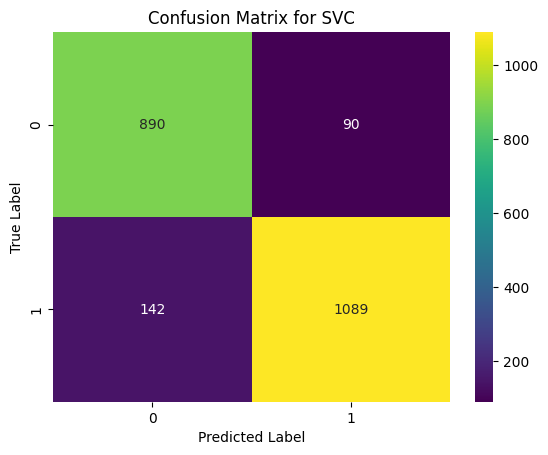

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276
1,KNN,0.885120,0.912236,0.878148
2,SVC,0.895070,0.923664,0.884647


In [28]:
metrics_calc("SVC", y_pred_svc, metrics_df)

In [29]:
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier()

In [30]:
y_pred_dt = dt_clf.predict(X_test)

Model: Decision Tree
Accuracy: 0.8924
Precision: 0.9226
Recall: 0.8806


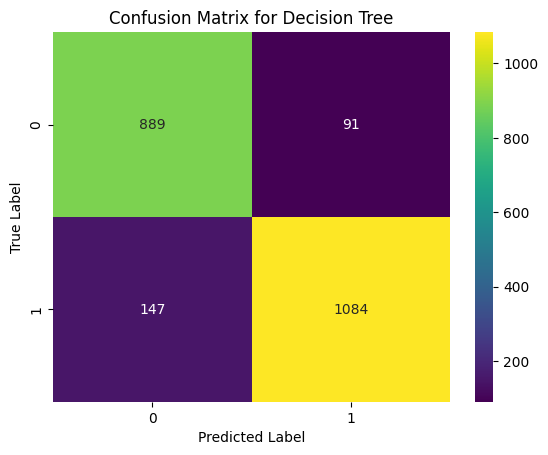

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276
1,KNN,0.885120,0.912236,0.878148
2,SVC,0.895070,0.923664,0.884647
3,Decision Tree,0.892356,0.922553,0.880585


In [31]:
metrics_calc("Decision Tree",y_pred_dt, metrics_df)

In [32]:
# RandomSearchCV for hyperparameter tuning of RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
params = {
    'n_estimators': [50,100, 200, 250, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4, 8],
    'bootstrap': [True, False]
}
rf1 = RandomForestClassifier()
rf_random = RandomizedSearchCV(estimator=rf1, param_distributions=params, n_iter=100, cv=3, verbose=2, random_state=42, n_jobs=-1)
rf_random.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END bootstrap=False, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=7, n_estimators=250; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=7, n_estimators=250; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=7, n_estimators=250; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=7, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=7, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=7, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; 

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=100,
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [10, 20, 30, 40, 50, None],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [1, 2, 4, 8],
                                        'min_samples_split': [2, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 250,
                                                         500]},
                   random_state=42, verbose=2)

In [33]:
y_pred_rf_random = rf_random.predict(X_test)

Model: Random Forest
Accuracy: 0.8933
Precision: 0.9205
Recall: 0.8846


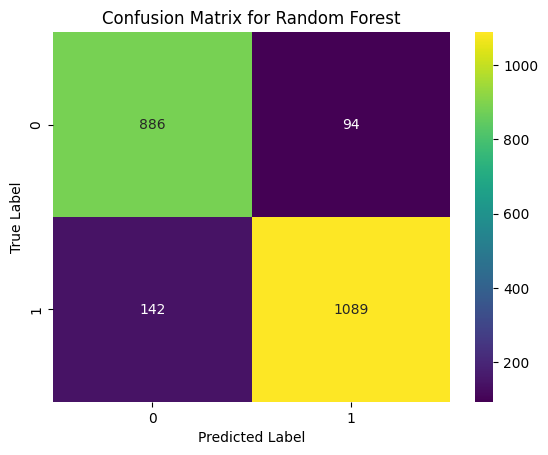

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276
1,KNN,0.885120,0.912236,0.878148
2,SVC,0.895070,0.923664,0.884647
3,Decision Tree,0.892356,0.922553,0.880585
4,Random Forest,0.893261,0.920541,0.884647


In [34]:
metrics_calc("Random Forest", y_pred_rf_random, metrics_df)

In [35]:
rf_random.best_params_

{'n_estimators': 250,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'log2',
 'max_depth': 50,
 'bootstrap': True}

In [36]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_random.best_estimator_.feature_importances_
})

In [37]:
feature_importance

,Feature,Importance
0,having_IP_Address,0.017444
1,having_Sub_Domain,0.105943
2,Request_URL,0.031781
3,URL_of_Anchor,0.136616
4,web_traffic,0.113854
5,url_obfuscation_score,0.104048
6,ui_deception_score,0.048295
7,trust_score,0.400753
8,redirection_risk_score,0.041264


In [38]:
from sklearn.ensemble import GradientBoostingClassifier
gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train, y_train)

GradientBoostingClassifier()

In [39]:
y_pred_gb = gb_clf.predict(X_test)

Model: Gradient Boosting
Accuracy: 0.8860
Precision: 0.9152
Recall: 0.8765


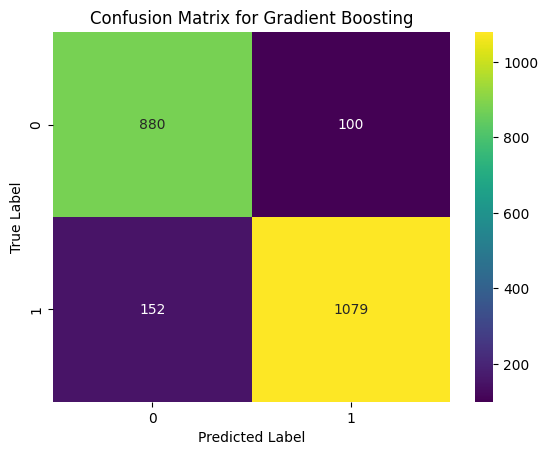

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276
1,KNN,0.885120,0.912236,0.878148
2,SVC,0.895070,0.923664,0.884647
3,Decision Tree,0.892356,0.922553,0.880585
4,Random Forest,0.893261,0.920541,0.884647
5,Gradient Boosting,0.886024,0.915182,0.876523


In [40]:
metrics_calc("Gradient Boosting", y_pred_gb, metrics_df)

In [41]:
from sklearn.ensemble import VotingClassifier
vc_clf = VotingClassifier(
    estimators=[
        ('lr', log_reg),
        ('svc', svc_grid),
        ('rf', rf_random)
    ],
    voting='hard'
)
vc_clf.fit(X_train, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END bootstrap=False, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=7, n_estimators=250; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=7, n_estimators=250; total time=   0.0s
[CV] END bootstrap=False, max_depth=10, max_features=auto, min_samples_leaf=1, min_samples_split=7, n_estimators=250; total time=   0.0s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=7, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=7, n_estimators=100; total time=   0.2s
[CV] END bootstrap=True, max_depth=20, max_features=log2, min_samples_leaf=8, min_samples_split=7, n_estimators=100; total time=   0.2s
[CV] END bootstrap=False, max_depth=10, max_features=log2, min_samples_leaf=1, min_samples_split=2, n_estimators=100; 

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('svc',
                              GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
                                           param_grid=[{'C': [0.1, 1, 10],
                                                        'class_weight': [None,
                                                                         'balanced'],
                                                        'kernel': ['linear']},
                                                       {'C': [0.1, 1, 10],
                                                        'class_weight': [None,
                                                                         'balanced'],
                                                        'gamma': ['scale', 0.5,
                                                                  0.1],
                                                        'kernel': ['rbf']}],
                                           scoring='f1')),
                             ('rf',
                              RandomizedSearchCV(cv=3,
                                                 estimator=RandomForestClassifier(),
                                                 n_iter=100, n_jobs=-1,
                                                 param_distributions={'bootstrap': [True,
                                                                                    False],
                                                                      'max_depth': [10,
                                                                                    20,
                                                                                    30,
                                                                                    40,
                                                                                    50,
                                                                                    None],
                                                                      'max_features': ['auto',
                                                                                       'sqrt',
                                                                                       'log2'],
                                                                      'min_samples_leaf': [1,
                                                                                           2,
                                                                                           4,
                                                                                           8],
                                                                      'min_samples_split': [2,
                                                                                            5,
                                                                                            7,
                                                                                            10],
                                                                      'n_estimators': [50,
                                                                                       100,
                                                                                       200,
                                                                                       250,
                                                                                       500]},
                                                 random_state=42, verbose=2))])

In [42]:
y_pred_vote = vc_clf.predict(X_test)

Model: Voting Classifier
Accuracy: 0.8969
Precision: 0.9254
Recall: 0.8863


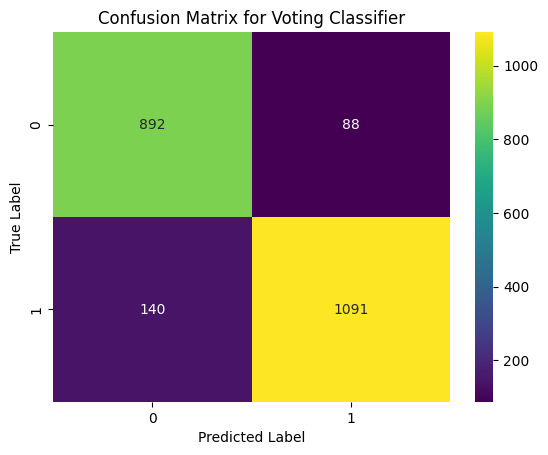

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276
1,KNN,0.885120,0.912236,0.878148
2,SVC,0.895070,0.923664,0.884647
3,Decision Tree,0.892356,0.922553,0.880585
4,Random Forest,0.893261,0.920541,0.884647
5,Gradient Boosting,0.886024,0.915182,0.876523
6,Voting Classifier,0.896879,0.925360,0.886271


In [43]:
metrics_calc("Voting Classifier", y_pred_vote, metrics_df)

In [44]:
from sklearn.ensemble import AdaBoostClassifier
adb_clf = AdaBoostClassifier()
adb_clf.fit(X_train,y_train)

AdaBoostClassifier()

In [45]:
y_pred_adf = adb_clf.predict(X_test)

Model: AdaBoost
Accuracy: 0.8666
Precision: 0.8973
Recall: 0.8587


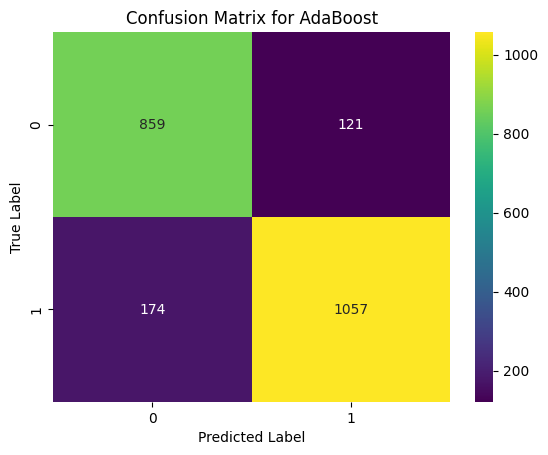

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.862506,0.889169,0.860276
1,KNN,0.885120,0.912236,0.878148
2,SVC,0.895070,0.923664,0.884647
3,Decision Tree,0.892356,0.922553,0.880585
4,Random Forest,0.893261,0.920541,0.884647
5,Gradient Boosting,0.886024,0.915182,0.876523
6,Voting Classifier,0.896879,0.925360,0.886271
7,AdaBoost,0.866576,0.897284,0.858652


In [46]:
metrics_calc("AdaBoost",y_pred_adf,metrics_df)

In [47]:
metrics_df = metrics_df.round(4).sort_values(by='Recall', ascending=False,ignore_index=True)
metrics_df

,Model,Accuracy,Precision,Recall
0,Voting Classifier,0.8969,0.9254,0.8863
1,SVC,0.8951,0.9237,0.8846
2,Random Forest,0.8933,0.9205,0.8846
3,Decision Tree,0.8924,0.9226,0.8806
4,KNN,0.8851,0.9122,0.8781
5,Gradient Boosting,0.8860,0.9152,0.8765
6,Logistic Regression,0.8625,0.8892,0.8603
7,AdaBoost,0.8666,0.8973,0.8587
